In [128]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026/publisher_summary.csv
/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026/yearly_trends.csv
/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026/genre_summary.csv
/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026/platform_summary.csv
/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026/train_games.csv
/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026/test_features.csv


In [129]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files:
        print("   ", file)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/datasets
/kaggle/input/datasets/pushkarsingh20
/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026
    publisher_summary.csv
    yearly_trends.csv
    genre_summary.csv
    platform_summary.csv
    train_games.csv
    test_features.csv


In [130]:
# ============================================================
# ML.ai Hackathon 2026
# Competition Grade Notebook
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [131]:
DATA_PATH = Path("/kaggle/input/datasets/pushkarsingh20/ml-ai-hackathon-2026")

train = pd.read_csv(DATA_PATH/"train_games.csv")
test = pd.read_csv(DATA_PATH/"test_features.csv")

genre_summary = pd.read_csv(DATA_PATH/"genre_summary.csv")
platform_summary = pd.read_csv(DATA_PATH/"platform_summary.csv")
publisher_summary = pd.read_csv(DATA_PATH/"publisher_summary.csv")
yearly_trends = pd.read_csv(DATA_PATH/"yearly_trends.csv")

print(train.shape)
print(test.shape)

(40000, 34)
(10000, 33)


In [132]:
def reduce_memory_usage(df):

    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:

        col_type = df[col].dtype

        if col_type != object:

            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == "int":

                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)

                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)

                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            else:

                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)

                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2

    print(f"Reduced {start_mem:.2f} MB -> {end_mem:.2f} MB")

    return df

In [133]:
train = reduce_memory_usage(train)
test = reduce_memory_usage(test)

Reduced 10.38 MB -> 5.15 MB
Reduced 2.52 MB -> 1.27 MB


In [134]:
print("="*60)
print("TRAIN")
print("="*60)

display(train.head())

print(train.shape)

display(train.describe(include='all').T)

TRAIN


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,publisher_is_developer,internal_build_id,marketing_campaign_type,day_one_patch_size_mb
0,G000019,Night in the Saga,Atari 2600,Console,Atari,2,Adventure,1985,Take-Two Interactive,Raw Fury,USA,AAA,T,87.1875,9.000000,12.585938,423.750000,262.00,39.59375,0,0,1,0,0,0,0,0,0,16.500000,72.68750,0,E571DCF3,NaN,7534
1,G000129,Metal Gear Legend,Atari 2600,Console,Atari,2,Idle/Clicker,1985,Nintendo,Larian Studios,Japan,AAA,E,71.8750,7.750000,29.328125,17.250000,706.00,39.71875,0,0,1,0,0,0,0,0,0,10.601562,44.50000,0,DA796E03,Campaign_C,13313
2,G000192,FIFA 2024,NES,Console,Nintendo,3,Sports,1985,FromSoftware,Activision Blizzard,Japan,AAA,T,78.1875,6.027344,33.218750,22.953125,1677.00,48.68750,1,1,0,0,0,0,0,0,0,14.000000,63.09375,0,7C30DA4B,Campaign_C,11487
3,G000200,Tales of World,NES,Console,Nintendo,3,Role-Playing,1985,Ubisoft,Toby Fox,France,AAA,T,76.1875,6.808594,62.937500,111.062500,108.25,40.84375,0,1,0,0,0,0,0,0,0,66.187500,152.12500,0,D75B1F62,NaN,12498
4,G000254,God of Shadow,PC,PC,Various,0,Action,1985,Nintendo,Nintendo,Japan,AAA,E10+,74.0000,6.289062,33.437500,NaN,670.00,22.25000,0,0,1,0,0,0,0,0,0,10.398438,27.40625,1,049CF258,Campaign_B,1917


(40000, 34)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
game_id,40000,40000,G000019,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,40000,1389,Devil May Strike,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,40000,30,PC,4939,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform_type,40000,7,Console,21142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform_maker,40000,8,Nintendo,14924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform_generation,40000.0,NaN,NaN,NaN,4.171725,2.864305,0.0,2.0,4.0,7.0,9.0
genre,40000,20,Action,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,40000.0,NaN,NaN,NaN,2003.6252,9.745106,1985.0,1996.0,2004.0,2012.0,2019.0
publisher,40000,51,Sony Interactive,1294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,40000,51,Sega,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
print("="*60)
print("TEST")
print("="*60)

display(test.head())

print(test.shape)

TEST


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,publisher_is_developer,internal_build_id,marketing_campaign_type,day_one_patch_size_mb
0,G016973,World of Warcraft: Eternal,Mobile (Android),Mobile,Google,0,MMORPG,2024,Double Fine,Double Fine,USA,AA,E10+,70.0,7.699219,8.0,13.0,4.988281,0,1,1,1,1,0,0,0,0,179.125000,843.500000,1,AFC3DF21,Campaign_C,2770
1,G011036,Counter-Strike : Redux,Mobile (Android),Mobile,Google,0,Shooter,2023,Unknown Worlds,Unknown Worlds,USA,Indie,M,NaN,7.101562,7.0,196.0,4.988281,0,1,0,1,1,1,0,0,0,6.101562,17.796875,1,488E1537,Campaign_A,10980
2,G000593,Euro Truck Simulator 2,PC,PC,Various,0,Simulation,2021,Devolver Digital,Devolver Digital,USA,AA,M,67.0,7.300781,116.0,252.0,50.000000,1,1,1,0,0,0,0,0,0,13.203125,61.406250,1,40541EDB,Campaign_A,12403
3,G013281,Rise of the Reborn,Stadia,Streaming,Google,9,Action,2023,Remedy Entertainment,Remedy Entertainment,Finland,AA,E,NaN,6.101562,7.0,468.0,14.992188,0,0,1,0,0,0,0,0,0,10.101562,27.203125,1,BAF5660F,Campaign_C,14374
4,G004160,Professor Layton and the Saga,PlayStation 4,Console,Sony,8,Puzzle,2023,Double Fine,Double Fine,USA,AA,M,49.0,3.800781,5.0,6.0,60.000000,0,1,1,0,0,0,0,0,0,8.398438,21.500000,1,21D7C371,Campaign_A,5114


(10000, 33)


In [136]:
print("="*60)
print("Duplicate Rows")
print("="*60)

print(train.duplicated().sum())
print(test.duplicated().sum())

print()

print("="*60)
print("Duplicate Game IDs")
print("="*60)

print(train["game_id"].duplicated().sum())
print(test["game_id"].duplicated().sum())

Duplicate Rows
0
0

Duplicate Game IDs
0
0


In [137]:
missing = pd.DataFrame({

    "Missing":train.isnull().sum(),

    "Percentage":100*train.isnull().mean()

})

missing = missing.sort_values("Percentage",ascending=False)

display(missing)

,Missing,Percentage
marketing_campaign_type,9995,24.9875
critic_review_count,6000,15.0000
metacritic_score,6000,15.0000
user_review_count,6000,15.0000
title,0,0.0000
game_id,0,0.0000
genre,0,0.0000
platform_type,0,0.0000
platform_maker,0,0.0000
platform,0,0.0000


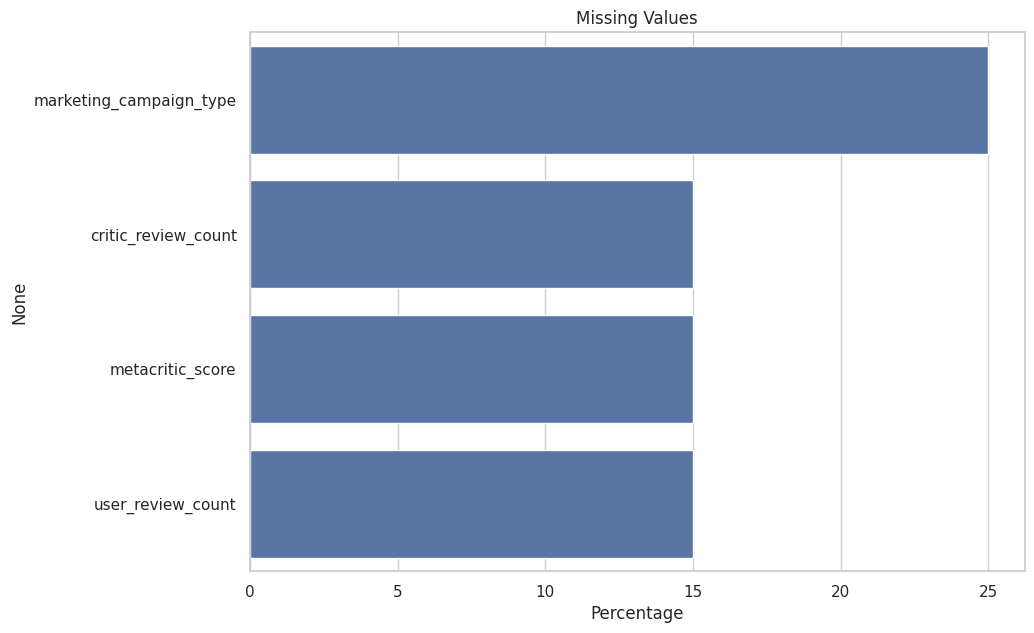

In [138]:
plt.figure(figsize=(10,7))

sns.barplot(

    data=missing[missing["Percentage"]>0],

    x="Percentage",

    y=missing[missing["Percentage"]>0].index

)

plt.title("Missing Values")

plt.show()

In [139]:
TARGET = "estimated_revenue_million_usd"

train[TARGET].describe()

count    40000.0000
mean            inf
std             inf
min          0.0000
25%        102.3125
50%        309.2500
75%        749.5000
max      45696.0000
Name: estimated_revenue_million_usd, dtype: float64

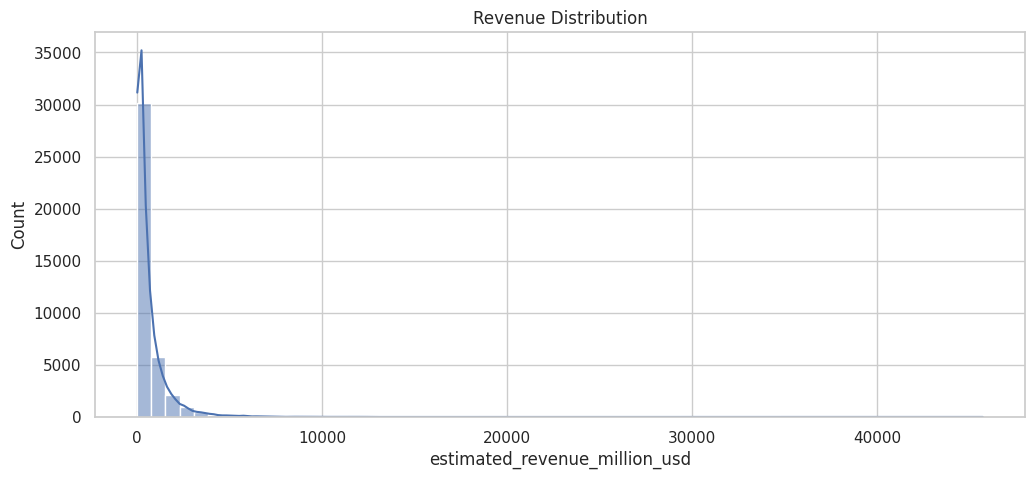

In [140]:
fig,ax=plt.subplots(figsize=(12,5))

sns.histplot(

    train[TARGET],

    bins=60,

    kde=True,

    ax=ax

)

plt.title("Revenue Distribution")

plt.show()

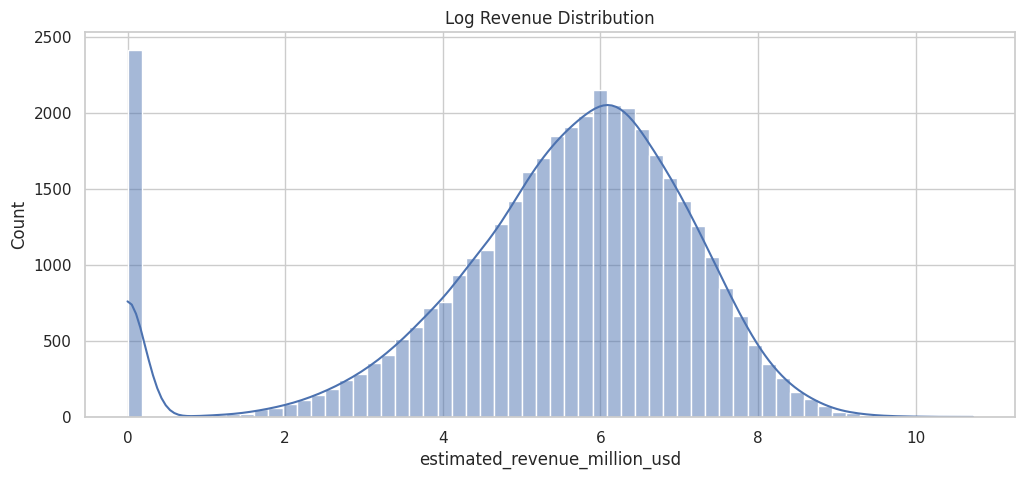

In [141]:
fig,ax=plt.subplots(figsize=(12,5))

sns.histplot(

    np.log1p(train[TARGET]),

    bins=60,

    kde=True,

    ax=ax

)

plt.title("Log Revenue Distribution")

plt.show()

In [142]:
print("Original Skew")

print(skew(train[TARGET]))

print()

print("Log Skew")

print(skew(np.log1p(train[TARGET])))

Original Skew
nan

Log Skew
-1.263


In [143]:
numerical_features = train.select_dtypes(include=np.number).columns.tolist()

categorical_features = train.select_dtypes(include="object").columns.tolist()

print(len(numerical_features))

print(len(categorical_features))

21
13


In [144]:
cardinality = pd.DataFrame({

    "Feature":categorical_features,

    "Unique":[train[c].nunique() for c in categorical_features]

})

display(cardinality.sort_values("Unique",ascending=False))

,Feature,Unique
0,game_id,40000
11,internal_build_id,40000
1,title,1389
6,publisher,51
7,developer,51
2,platform,30
5,genre,20
8,publisher_region,15
4,platform_maker,8
3,platform_type,7


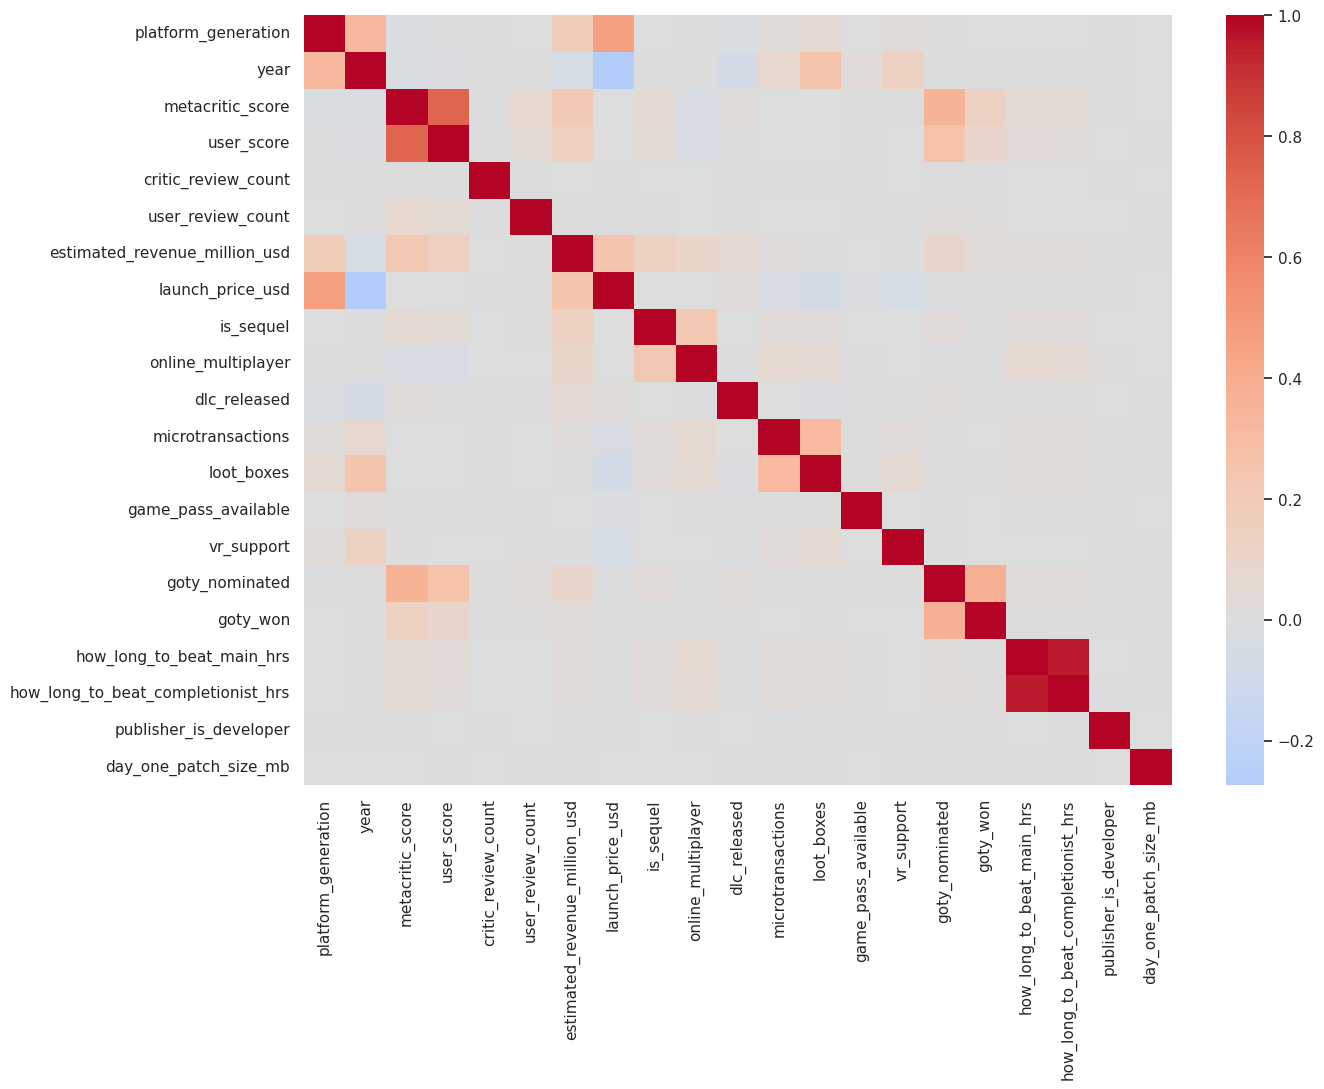

In [145]:
corr = train[numerical_features].corr()

plt.figure(figsize=(14,10))

sns.heatmap(

    corr,

    cmap="coolwarm",

    center=0

)

plt.show()

In [146]:
corr_target = (

    corr[TARGET]

    .sort_values(ascending=False)

)

display(corr_target)

estimated_revenue_million_usd         1.000000
launch_price_usd                      0.256228
metacritic_score                      0.219018
platform_generation                   0.183904
user_score                            0.159871
is_sequel                             0.144547
online_multiplayer                    0.105023
goty_nominated                        0.103279
dlc_released                          0.055457
goty_won                              0.032942
how_long_to_beat_main_hrs             0.021072
how_long_to_beat_completionist_hrs    0.016170
microtransactions                     0.015789
user_review_count                     0.010023
day_one_patch_size_mb                 0.009629
loot_boxes                            0.009193
publisher_is_developer                0.000162
game_pass_available                  -0.003869
critic_review_count                  -0.004690
vr_support                           -0.013217
year                                 -0.051000
Name: estimat

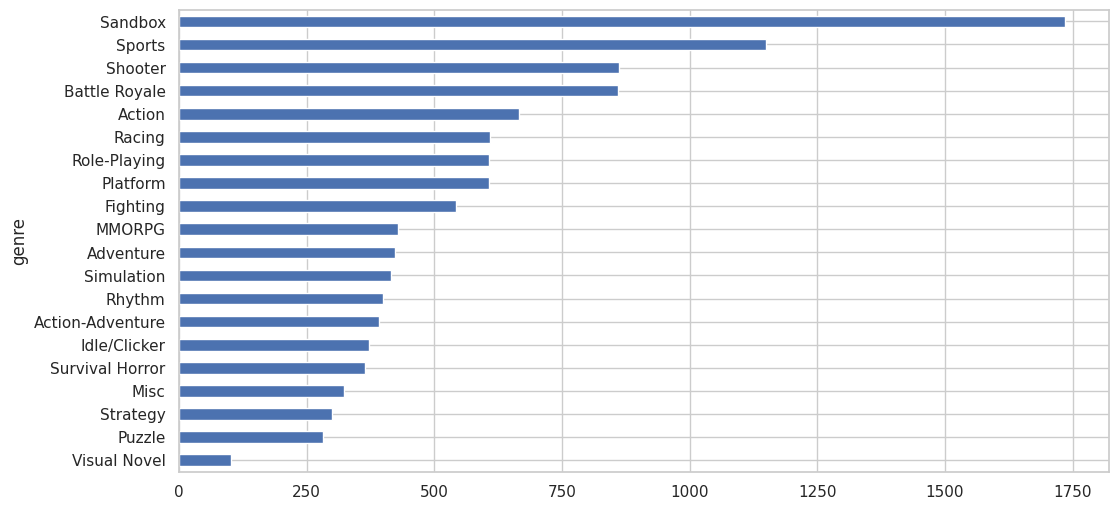

In [147]:
plt.figure(figsize=(12,6))

(

train.groupby("genre")[TARGET]

.mean()

.sort_values()

.plot(kind="barh")

)

plt.show()

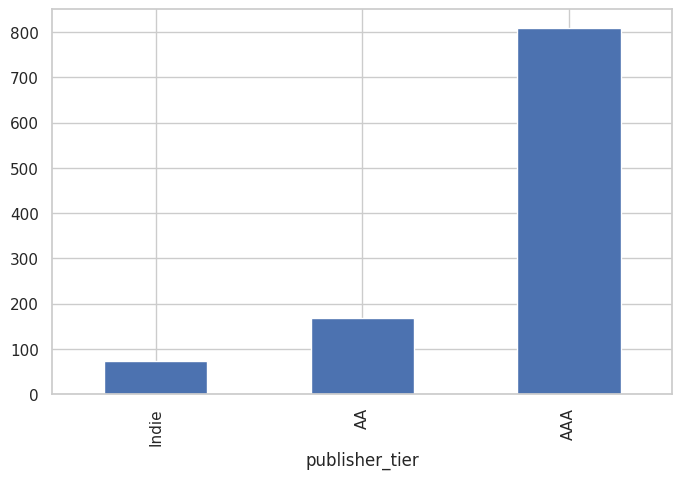

In [148]:
plt.figure(figsize=(8,5))

(

train.groupby("publisher_tier")[TARGET]

.mean()

.sort_values()

.plot(kind="bar")

)

plt.show()

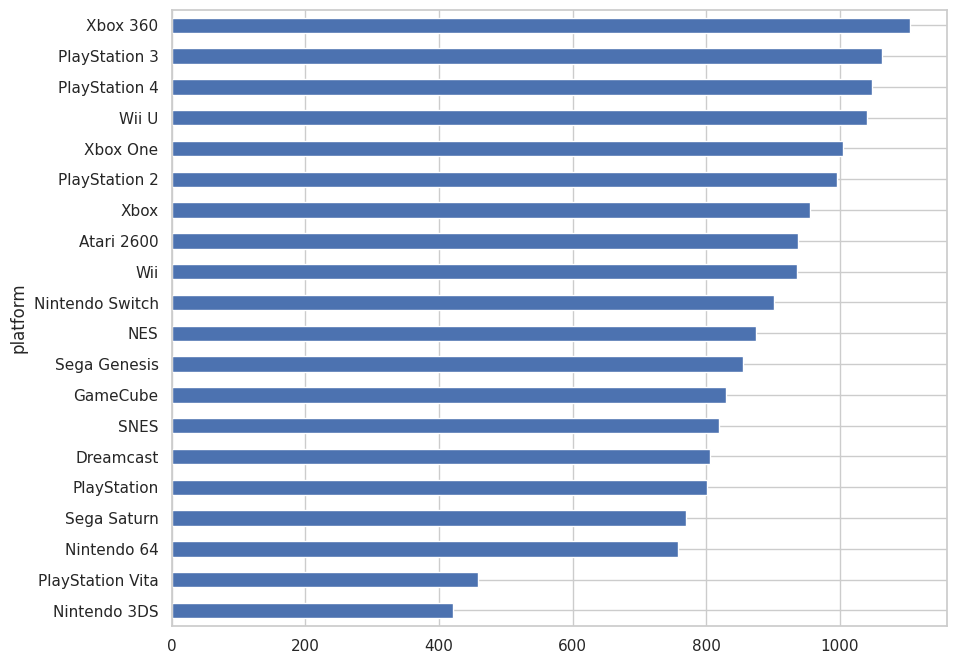

In [149]:
top_platforms=(

train.groupby("platform")[TARGET]

.mean()

.sort_values()

.tail(20)

)

plt.figure(figsize=(10,8))

top_platforms.plot(kind="barh")

plt.show()

In [150]:
tables = {
    "Genre Summary": genre_summary,
    "Platform Summary": platform_summary,
    "Publisher Summary": publisher_summary,
    "Yearly Trends": yearly_trends
}

for name, df in tables.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(df.shape)
    display(df.head())

Genre Summary
(138, 10)


,genre,platform_type,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_online_multiplayer,pct_dlc_released,pct_microtransactions
0,Action,Browser,330,0.000000,73.179441,7.275458,0.005587,0.281818,0.606061,0.196970
1,Action,Console,3115,964.650408,73.524403,7.356233,59.786596,0.298555,0.637560,0.241413
2,Action,Handheld,1256,439.666250,73.731868,7.387525,34.848484,0.276274,0.621019,0.249204
3,Action,Hybrid,69,1068.038841,73.674123,7.326463,44.876496,0.304348,0.695652,0.260870
4,Action,Mobile,420,193.212643,74.085411,7.423656,2.364155,0.276190,0.638095,0.288095


Platform Summary
(30, 8)


,platform,platform_generation,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_online_multiplayer
0,Atari 2600,2,1607,936.901307,75.291523,7.514181,59.705971,0.504667
1,Browser,0,2299,0.000000,73.886459,7.392355,-0.001256,0.494563
2,Dreamcast,6,498,806.225141,74.032299,7.439961,59.410105,0.510040
3,Game Boy,4,2107,358.033806,74.297295,7.402152,34.798595,0.495966
4,Game Boy Advance,6,1094,378.153556,73.031227,7.341233,34.670368,0.510969


Publisher Summary
(51, 8)


,publisher,publisher_tier,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_sequel
0,2K Games,AAA,1203,822.521671,75.834215,7.595432,45.095605,0.404821
1,505 Games,AA,564,170.252996,68.025676,6.873583,41.494612,0.393617
2,Activision Blizzard,AAA,1175,790.378817,75.370783,7.559883,45.086469,0.414468
3,Annapurna Interactive,Indie,247,62.848057,71.267194,7.206517,40.280486,0.421053
4,Bandai Namco,AAA,1284,871.279276,75.470130,7.580445,45.565369,0.436916


Yearly Trends
(700, 7)


,year,genre,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd
0,1985,Action,131,783.051145,74.304300,7.578511,51.500974
1,1985,Action-Adventure,27,565.533333,73.160241,7.389119,54.254196
2,1985,Adventure,38,532.396053,78.325365,7.543377,46.691237
3,1985,Battle Royale,18,913.812778,76.561945,7.447295,38.353663
4,1985,Fighting,50,512.874400,76.523869,7.536959,47.565301


In [151]:
for name, df in tables.items():
    print("="*60)
    print(name)

    print(df.columns.tolist())

Genre Summary
['genre', 'platform_type', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd', 'pct_online_multiplayer', 'pct_dlc_released', 'pct_microtransactions']
Platform Summary
['platform', 'platform_generation', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd', 'pct_online_multiplayer']
Publisher Summary
['publisher', 'publisher_tier', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd', 'pct_sequel']
Yearly Trends
['year', 'genre', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd']


In [152]:
TARGET = "estimated_revenue_million_usd"

train["is_train"] = 1
test["is_train"] = 0

test[TARGET] = np.nan

full = pd.concat([train, test], ignore_index=True)

print(full.shape)

(50000, 35)


In [153]:
missing_cols = full.columns[full.isnull().sum() > 0]

for col in missing_cols:
    full[col + "_missing"] = full[col].isnull().astype("int8")

In [154]:
numeric_cols = full.select_dtypes(include=np.number).columns

categorical_cols = full.select_dtypes(include="object").columns

for col in numeric_cols:

    if col != TARGET:
        full[col] = full[col].fillna(full[col].median())

for col in categorical_cols:

    full[col] = full[col].fillna("Unknown")

In [155]:
full["title_length"] = full["title"].str.len()

full["title_words"] = full["title"].str.split().str.len()

full["contains_remastered"] = full["title"].str.contains(
    "Remastered",
    case=False,
    na=False
).astype(int)

full["contains_deluxe"] = full["title"].str.contains(
    "Deluxe",
    case=False,
    na=False
).astype(int)

full["contains_hd"] = full["title"].str.contains(
    "HD",
    case=False,
    na=False
).astype(int)

full["contains_collection"] = full["title"].str.contains(
    "Collection",
    case=False,
    na=False
).astype(int)

In [156]:
roman = r"\b(ii|iii|iv|v|vi|vii|viii|ix|x)\b"

full["has_roman"] = (
    full["title"]
    .str.contains(roman, case=False, regex=True)
    .astype(int)
)

full["has_number"] = (
    full["title"]
    .str.contains(r"\d")
    .astype(int)
)

In [157]:
full["completion_ratio"] = (
    full["how_long_to_beat_completionist_hrs"] /
    (full["how_long_to_beat_main_hrs"] + 1)
)

full["extra_hours"] = (
    full["how_long_to_beat_completionist_hrs"] -
    full["how_long_to_beat_main_hrs"]
)

full["price_per_hour"] = (
    full["launch_price_usd"] /
    (full["how_long_to_beat_main_hrs"] + 1)
)

In [158]:
full["critic_user_ratio"] = (
    full["critic_review_count"] /
    (full["user_review_count"] + 1)
)

full["total_reviews"] = (
    full["critic_review_count"] +
    full["user_review_count"]
)

full["review_difference"] = (
    full["critic_review_count"] -
    full["user_review_count"]
)

In [159]:
full["critic_score_x_reviews"] = (
    full["metacritic_score"] *
    full["critic_review_count"]
)

full["user_score_x_reviews"] = (
    full["user_score"] *
    full["user_review_count"]
)

full["price_x_meta"] = (
    full["launch_price_usd"] *
    full["metacritic_score"]
)

full["price_x_user"] = (
    full["launch_price_usd"] *
    full["user_score"]
)

In [160]:
binary_cols = [

"is_sequel",

"online_multiplayer",

"dlc_released",

"microtransactions",

"loot_boxes",

"game_pass_available",

"vr_support",

"goty_nominated",

"goty_won",

"publisher_is_developer"

]

full["binary_feature_sum"] = full[binary_cols].sum(axis=1)

In [161]:
latest_year = full["year"].max()

full["game_age"] = latest_year - full["year"]

In [162]:
for name, df in {
    "Genre": genre_summary,
    "Platform": platform_summary,
    "Publisher": publisher_summary,
    "Yearly": yearly_trends
}.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(df.columns.tolist())

    display(df.head())

Genre
['genre', 'platform_type', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd', 'pct_online_multiplayer', 'pct_dlc_released', 'pct_microtransactions']


,genre,platform_type,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_online_multiplayer,pct_dlc_released,pct_microtransactions
0,Action,Browser,330,0.000000,73.179441,7.275458,0.005587,0.281818,0.606061,0.196970
1,Action,Console,3115,964.650408,73.524403,7.356233,59.786596,0.298555,0.637560,0.241413
2,Action,Handheld,1256,439.666250,73.731868,7.387525,34.848484,0.276274,0.621019,0.249204
3,Action,Hybrid,69,1068.038841,73.674123,7.326463,44.876496,0.304348,0.695652,0.260870
4,Action,Mobile,420,193.212643,74.085411,7.423656,2.364155,0.276190,0.638095,0.288095


Platform
['platform', 'platform_generation', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd', 'pct_online_multiplayer']


,platform,platform_generation,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_online_multiplayer
0,Atari 2600,2,1607,936.901307,75.291523,7.514181,59.705971,0.504667
1,Browser,0,2299,0.000000,73.886459,7.392355,-0.001256,0.494563
2,Dreamcast,6,498,806.225141,74.032299,7.439961,59.410105,0.510040
3,Game Boy,4,2107,358.033806,74.297295,7.402152,34.798595,0.495966
4,Game Boy Advance,6,1094,378.153556,73.031227,7.341233,34.670368,0.510969


Publisher
['publisher', 'publisher_tier', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd', 'pct_sequel']


,publisher,publisher_tier,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd,pct_sequel
0,2K Games,AAA,1203,822.521671,75.834215,7.595432,45.095605,0.404821
1,505 Games,AA,564,170.252996,68.025676,6.873583,41.494612,0.393617
2,Activision Blizzard,AAA,1175,790.378817,75.370783,7.559883,45.086469,0.414468
3,Annapurna Interactive,Indie,247,62.848057,71.267194,7.206517,40.280486,0.421053
4,Bandai Namco,AAA,1284,871.279276,75.470130,7.580445,45.565369,0.436916


Yearly
['year', 'genre', 'titles', 'avg_estimated_revenue_million_usd', 'avg_metacritic_score', 'avg_user_score', 'avg_launch_price_usd']


,year,genre,titles,avg_estimated_revenue_million_usd,avg_metacritic_score,avg_user_score,avg_launch_price_usd
0,1985,Action,131,783.051145,74.304300,7.578511,51.500974
1,1985,Action-Adventure,27,565.533333,73.160241,7.389119,54.254196
2,1985,Adventure,38,532.396053,78.325365,7.543377,46.691237
3,1985,Battle Royale,18,913.812778,76.561945,7.447295,38.353663
4,1985,Fighting,50,512.874400,76.523869,7.536959,47.565301


In [163]:
# ============================================================
# Merge Genre Summary
# ============================================================

full = full.merge(
    genre_summary,
    how="left",
    on=["genre", "platform_type"],
    suffixes=("", "_genre")
)

print(full.shape)

(50000, 68)


In [164]:
# ============================================================
# Merge Platform Summary
# ============================================================

full = full.merge(
    platform_summary,
    how="left",
    on=["platform", "platform_generation"],
    suffixes=("", "_platform")
)

print(full.shape)

(50000, 74)


In [165]:
# ============================================================
# Merge Publisher Summary
# ============================================================

full = full.merge(
    publisher_summary,
    how="left",
    on=["publisher", "publisher_tier"],
    suffixes=("", "_publisher")
)

print(full.shape)

(50000, 80)


In [166]:
# ============================================================
# Merge Yearly Trends
# ============================================================

full = full.merge(
    yearly_trends,
    how="left",
    on=["year", "genre"],
    suffixes=("", "_year")
)

print(full.shape)

(50000, 85)


In [167]:
new_cols = [c for c in full.columns if c not in train.columns]

print(f"New Columns Added: {len(new_cols)}")
print()

for col in new_cols:
    print(col)

New Columns Added: 50

metacritic_score_missing
critic_review_count_missing
user_review_count_missing
estimated_revenue_million_usd_missing
marketing_campaign_type_missing
title_length
title_words
contains_remastered
contains_deluxe
contains_hd
contains_collection
has_roman
has_number
completion_ratio
extra_hours
price_per_hour
critic_user_ratio
total_reviews
review_difference
critic_score_x_reviews
user_score_x_reviews
price_x_meta
price_x_user
binary_feature_sum
game_age
titles
avg_estimated_revenue_million_usd
avg_metacritic_score
avg_user_score
avg_launch_price_usd
pct_online_multiplayer
pct_dlc_released
pct_microtransactions
titles_platform
avg_estimated_revenue_million_usd_platform
avg_metacritic_score_platform
avg_user_score_platform
avg_launch_price_usd_platform
pct_online_multiplayer_platform
titles_publisher
avg_estimated_revenue_million_usd_publisher
avg_metacritic_score_publisher
avg_user_score_publisher
avg_launch_price_usd_publisher
pct_sequel
titles_year
avg_estimated_re

In [168]:
full["meta_vs_genre_avg"] = (
    full["metacritic_score"] -
    full["avg_metacritic_score"]
)

full["user_vs_genre_avg"] = (
    full["user_score"] -
    full["avg_user_score"]
)

full["price_vs_genre_avg"] = (
    full["launch_price_usd"] -
    full["avg_launch_price_usd"]
)

In [169]:
full["meta_vs_platform_avg"] = (
    full["metacritic_score"] -
    full["avg_metacritic_score_platform"]
)

full["user_vs_platform_avg"] = (
    full["user_score"] -
    full["avg_user_score_platform"]
)

full["price_vs_platform_avg"] = (
    full["launch_price_usd"] -
    full["avg_launch_price_usd_platform"]
)

In [170]:
full["meta_vs_publisher_avg"] = (
    full["metacritic_score"] -
    full["avg_metacritic_score_publisher"]
)

full["user_vs_publisher_avg"] = (
    full["user_score"] -
    full["avg_user_score_publisher"]
)

full["price_vs_publisher_avg"] = (
    full["launch_price_usd"] -
    full["avg_launch_price_usd_publisher"]
)

In [171]:
full["genre_expected_revenue"] = full["avg_estimated_revenue_million_usd"]

full["platform_expected_revenue"] = full["avg_estimated_revenue_million_usd_platform"]

full["publisher_expected_revenue"] = full["avg_estimated_revenue_million_usd_publisher"]

full["year_expected_revenue"] = full["avg_estimated_revenue_million_usd_year"]

In [172]:
full["price_to_genre_avg"] = (
    full["launch_price_usd"] /
    (full["avg_launch_price_usd"] + 1)
)

full["price_to_platform_avg"] = (
    full["launch_price_usd"] /
    (full["avg_launch_price_usd_platform"] + 1)
)

full["price_to_publisher_avg"] = (
    full["launch_price_usd"] /
    (full["avg_launch_price_usd_publisher"] + 1)
)

In [173]:
full["quality_index"] = (
    full["metacritic_score"] * 0.7 +
    full["user_score"] * 10 * 0.3
)

In [174]:
full["review_index"] = (
    np.log1p(full["critic_review_count"]) +
    np.log1p(full["user_review_count"])
)

In [175]:
full["commercial_score"] = (
    full["quality_index"] *
    full["review_index"]
)

In [176]:
#Advanced Feature Engineering

In [177]:
# ============================================================
# Publisher Strength Features
# ============================================================

full["publisher_revenue_power"] = (
    full["avg_estimated_revenue_million_usd_publisher"] *
    full["titles_publisher"]
)

full["publisher_quality_power"] = (
    full["avg_metacritic_score_publisher"] *
    full["avg_user_score_publisher"]
)

full["publisher_success_index"] = (
    full["publisher_revenue_power"] *
    full["publisher_quality_power"]
)

In [178]:
# ============================================================
# Platform Strength
# ============================================================

full["platform_revenue_power"] = (
    full["avg_estimated_revenue_million_usd_platform"] *
    full["titles_platform"]
)

full["platform_quality"] = (
    full["avg_metacritic_score_platform"] *
    full["avg_user_score_platform"]
)

full["platform_success_index"] = (
    full["platform_revenue_power"] *
    full["platform_quality"]
)

In [179]:
# ============================================================
# Genre Strength
# ============================================================

full["genre_success"] = (
    full["avg_estimated_revenue_million_usd"] *
    full["titles"]
)

full["genre_quality"] = (
    full["avg_metacritic_score"] *
    full["avg_user_score"]
)

full["genre_strength"] = (
    full["genre_success"] *
    full["genre_quality"]
)

In [180]:
full["franchise_score"] = (
    full["is_sequel"] *
    full["review_index"]
)

full["franchise_quality"] = (
    full["is_sequel"] *
    full["quality_index"]
)

In [181]:
full["award_score"] = (
    full["goty_nominated"] +
    full["goty_won"] * 2
)

full["award_quality"] = (
    full["award_score"] *
    full["quality_index"]
)

In [182]:
full["online_ecosystem"] = (

    full["online_multiplayer"] +

    full["dlc_released"] +

    full["microtransactions"] +

    full["loot_boxes"] +

    full["game_pass_available"]

)

In [183]:
full["premium_index"] = (

    full["launch_price_usd"] *

    full["quality_index"]

)

In [184]:
full["hours_value"] = (

    full["quality_index"] *

    full["how_long_to_beat_main_hrs"]

)

full["completion_value"] = (

    full["quality_index"] *

    full["how_long_to_beat_completionist_hrs"]

)

In [185]:
full["review_quality"] = (

    full["review_index"] *

    full["quality_index"]

)

full["review_price"] = (

    full["review_index"] *

    full["launch_price_usd"]

)

In [186]:
full["vr_multiplayer"] = (
    full["vr_support"] *
    full["online_multiplayer"]
)

full["dlc_micro"] = (
    full["dlc_released"] *
    full["microtransactions"]
)

full["publisher_dev"] = (
    full["publisher_is_developer"] *
    full["quality_index"]
)

In [187]:
log_cols = [

    "critic_review_count",

    "user_review_count",

    "launch_price_usd",

    "how_long_to_beat_main_hrs",

    "how_long_to_beat_completionist_hrs",

    "day_one_patch_size_mb"

]

for col in log_cols:

    full[f"log_{col}"] = np.log1p(full[col])

In [188]:
# ============================================================
# Leakage-safe Frequency Encoding
# ============================================================

freq_cols = [
    "publisher",
    "developer",
    "platform",
    "genre",
    "platform_maker"
]

for col in freq_cols:

    freq = train[col].value_counts(normalize=True)

    full[f"{col}_freq"] = full[col].map(freq).fillna(0)

In [189]:
# ============================================================
# Count Encoding
# ============================================================

count_cols = [
    "publisher",
    "developer",
    "platform",
    "genre"
]

for col in count_cols:

    counts = train[col].value_counts()

    full[f"{col}_count"] = full[col].map(counts).fillna(0)

In [190]:
for col in [

    "publisher",

    "developer"

]:

    counts = full.groupby(col)["game_id"].transform("count")

    full[col + "_count"] = counts

In [191]:
gc.collect()

print(full.shape)

print(full.memory_usage().sum()/1024**2,"MB")

(50000, 141)
36.049015045166016 MB


**Automatic Feature Selection**

In [192]:
# ============================================================
# Split back into train and test
# ============================================================

train_df = full[full["is_train"] == 1].copy()
test_df = full[full["is_train"] == 0].copy()

train_df.drop(columns=["is_train"], inplace=True)
test_df.drop(columns=["is_train"], inplace=True)

print(train_df.shape)
print(test_df.shape)

(40000, 140)
(10000, 140)


In [193]:
# ============================================================
# Remove constant columns
# ============================================================

constant_cols = []

for col in train_df.columns:

    if train_df[col].nunique(dropna=False) <= 1:
        constant_cols.append(col)

print(f"Constant Columns: {len(constant_cols)}")

train_df.drop(columns=constant_cols, inplace=True)
test_df.drop(columns=constant_cols, inplace=True)

constant_cols

Constant Columns: 4


['estimated_revenue_million_usd_missing',
 'contains_deluxe',
 'contains_hd',
 'contains_collection']

In [194]:
# ============================================================
# Remove duplicate columns
# ============================================================

duplicate_cols = []

cols = train_df.columns

for i in range(len(cols)):

    col1 = cols[i]

    for j in range(i + 1, len(cols)):

        col2 = cols[j]

        if train_df[col1].equals(train_df[col2]):
            duplicate_cols.append(col2)

print(f"Duplicate Columns: {len(duplicate_cols)}")

train_df.drop(columns=duplicate_cols, inplace=True)
test_df.drop(columns=duplicate_cols, inplace=True)

Duplicate Columns: 6


In [195]:
# ============================================================
# Correlation Filter
# ============================================================

TARGET = "estimated_revenue_million_usd"

numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

numeric_cols.remove(TARGET)

corr_matrix = train_df[numeric_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

drop_cols = [
    column
    for column in upper.columns
    if any(upper[column] > 0.98)
]

print(f"Highly Correlated Columns: {len(drop_cols)}")

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

Highly Correlated Columns: 32


In [196]:
missing = train_df.isnull().sum()

missing = missing[missing > 0]

print("Columns with Missing Values:")

display(missing.sort_values(ascending=False))

Columns with Missing Values:


review_index               1465
franchise_score            1465
commercial_score           1465
review_price               1465
log_user_review_count      1460
log_launch_price_usd        635
log_critic_review_count       5
avg_metacritic_score          1
meta_vs_genre_avg             1
dtype: int64

In [197]:
for col in train_df.columns:

    if train_df[col].dtype == "object":

        train_df[col].fillna("Unknown", inplace=True)
        test_df[col].fillna("Unknown", inplace=True)

    else:

        median = train_df[col].median(skipna=True)

        train_df[col].fillna(median, inplace=True)
        test_df[col].fillna(median, inplace=True)

In [198]:
print(f"Train Shape : {train_df.shape}")
print(f"Test Shape  : {test_df.shape}")

print()

print(
    "Memory:",
    train_df.memory_usage(deep=True).sum() / 1024**2,
    "MB"
)

Train Shape : (40000, 98)
Test Shape  : (10000, 98)

Memory: 43.521833419799805 MB


In [199]:
TARGET = "estimated_revenue_million_usd"

ID = "game_id"

categorical_features = train_df.select_dtypes(
    include="object"
).columns.tolist()

categorical_features.remove(ID)

numerical_features = train_df.select_dtypes(
    exclude="object"
).columns.tolist()

numerical_features.remove(TARGET)

print("Categorical :", len(categorical_features))
print("Numerical   :", len(numerical_features))

Categorical : 12
Numerical   : 84


In [200]:
feature_summary = pd.DataFrame({

    "Feature": train_df.columns,

    "Dtype": train_df.dtypes.astype(str),

    "Missing": train_df.isnull().sum(),

    "Unique": train_df.nunique()

})

display(feature_summary)

,Feature,Dtype,Missing,Unique
game_id,game_id,object,0,40000
title,title,object,0,1389
platform,platform,object,0,30
platform_type,platform_type,object,0,7
platform_maker,platform_maker,object,0,8
platform_generation,platform_generation,int8,0,9
genre,genre,object,0,20
year,year,int16,0,35
publisher,publisher,object,0,51
developer,developer,object,0,51


In [201]:
train_df.to_pickle("train_processed.pkl")
test_df.to_pickle("test_processed.pkl")

print("Saved processed datasets.")

Saved processed datasets.


In [202]:
# ============================================================
# PHASE 3 : MODEL TRAINING
# ============================================================

from dataclasses import dataclass

@dataclass
class CFG:

    TARGET = "estimated_revenue_million_usd"
    ID = "game_id"

    RANDOM_STATE = 42

    LOG_TARGET = True

    EARLY_STOPPING = 300

    VERBOSE = 200

    CAT_ITER = 5000
    LGB_ITER = 5000
    XGB_ITER = 5000

    CAT_LR = 0.03
    LGB_LR = 0.03
    XGB_LR = 0.03

In [203]:
import gc
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_log_error

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [204]:
TARGET = CFG.TARGET
ID = CFG.ID

X = train_df.drop(columns=[TARGET, ID]).copy()

X_test = test_df.drop(columns=[TARGET, ID]).copy()

if CFG.LOG_TARGET:
    y = np.log1p(train_df[TARGET])
else:
    y = train_df[TARGET]

years = train_df["year"].copy()

cat_features = X.select_dtypes(include="object").columns.tolist()

print("Train:", X.shape)
print("Test :", X_test.shape)
print("Categorical:", len(cat_features))

Train: (40000, 96)
Test : (10000, 96)
Categorical: 12


In [205]:
def rmsle(y_true, y_pred):

    y_pred = np.clip(y_pred, 0, None)

    return np.sqrt(
        mean_squared_log_error(
            y_true,
            y_pred
        )
    )

In [206]:
unique_years = np.sort(years.unique())

print(f"Unique Years: {len(unique_years)}")

folds = []

for split in range(3, len(unique_years)):

    train_years = unique_years[:split]
    valid_year = unique_years[split]

    train_idx = train_df.index[
        years.isin(train_years)
    ]

    valid_idx = train_df.index[
        years == valid_year
    ]

    if len(valid_idx) == 0:
        continue

    folds.append((train_idx, valid_idx))

print(f"Generated {len(folds)} time-based folds")

Unique Years: 35
Generated 32 time-based folds


In [207]:
# ==========================================================
# PHASE 3 : MODEL TRAINING
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import gc
import random

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error

from sklearn.preprocessing import OrdinalEncoder

from catboost import CatBoostRegressor

from lightgbm import LGBMRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ---------------- #

SEED = 42

N_SPLITS = 5

TARGET = "estimated_revenue_million_usd"

ID = "game_id"

random.seed(SEED)

np.random.seed(SEED)

In [208]:
# ==========================================================
# PREPARE DATA
# ==========================================================

# Copy so original DataFrames remain unchanged
train_model = train_df.copy()

test_model = test_df.copy()

# Target (log-space for RMSLE)
y = np.log1p(train_model[TARGET])

# Save IDs
test_ids = test_model[ID].copy()

# Features
X = train_model.drop(columns=[TARGET, ID])

X_test = test_model.drop(columns=[ID])

# Detect categorical columns
cat_cols = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

num_cols = [
    c for c in X.columns
    if c not in cat_cols
]

print("="*60)
print("Training Shape :", X.shape)
print("Testing Shape  :", X_test.shape)
print("Target Shape   :", y.shape)
print("="*60)

print(f"Categorical Features : {len(cat_cols)}")
print(f"Numerical Features   : {len(num_cols)}")

Training Shape : (40000, 96)
Testing Shape  : (10000, 97)
Target Shape   : (40000,)
Categorical Features : 12
Numerical Features   : 84


In [209]:
# ==========================================================
# ORDINAL ENCODING
# ==========================================================

encoder = OrdinalEncoder(

    handle_unknown="use_encoded_value",

    unknown_value=-1

)

X_lgb = X.copy()

X_test_lgb = X_test.copy()

X_lgb[cat_cols] = encoder.fit_transform(

    X_lgb[cat_cols]

)

X_test_lgb[cat_cols] = encoder.transform(

    X_test_lgb[cat_cols]

)

print("Encoding Complete.")

Encoding Complete.


In [210]:
# ==========================================================
# METRIC
# ==========================================================

def rmsle(

    y_true,

    y_pred

):

    y_true = np.expm1(y_true)

    y_pred = np.expm1(y_pred)

    y_pred = np.clip(

        y_pred,

        0,

        None

    )

    return np.sqrt(

        mean_squared_log_error(

            y_true,

            y_pred

        )

    )

# ==========================================================
# CROSS VALIDATION
# ==========================================================

kf = KFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED

)

# OOF predictions
oof_cat = np.zeros(len(X))

oof_lgb = np.zeros(len(X))

oof_xgb = np.zeros(len(X))

# Test predictions
pred_cat = np.zeros(len(X_test))

pred_lgb = np.zeros(len(X_test))

pred_xgb = np.zeros(len(X_test))

print("="*60)
print("Phase 3 Ready")
print(f"{N_SPLITS}-Fold Cross Validation")
print("="*60)

Phase 3 Ready
5-Fold Cross Validation
